In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Descargar una imagen de prueba si no tienes una
!wget -O imagen_test.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg

--2026-05-12 00:49:09--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44746 (44K) [image/jpeg]
Saving to: ‘imagen_test.jpg’

imagen_test.jpg     100%[===================>]  43.70K  --.-KB/s    in 0.001s  

2026-05-12 00:49:09 (44.5 MB/s) - ‘imagen_test.jpg’ saved [44746/44746]



Dimensiones de la matriz: (356, 493, 3)
Valor del píxel en (0,0): [47 88 50]


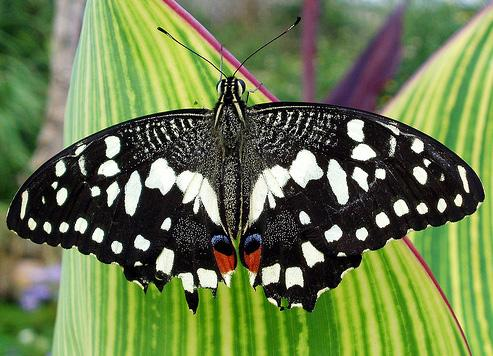

In [2]:
# Cargar imagen
img = cv2.imread('imagen_test.jpg')

# Ver dimensiones (Alto, Ancho, Canales)
print(f"Dimensiones de la matriz: {img.shape}")
print(f"Valor del píxel en (0,0): {img[0, 0]}") # Muestra los valores [B, G, R]

# Mostrar imagen original
cv2_imshow(img)

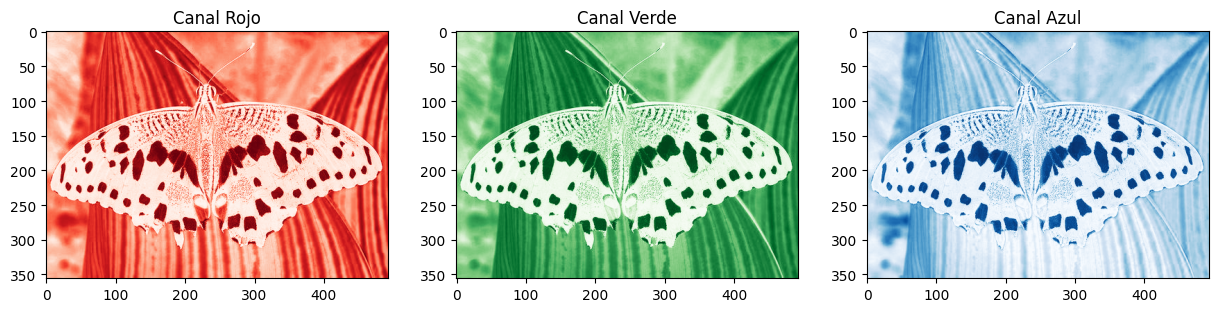

In [3]:
# Separar canales BGR
b, g, r = cv2.split(img)

# Convertir a HSV (Hue, Saturation, Value)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Visualizar con Matplotlib para comparar
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(r, cmap='Reds'); plt.title('Canal Rojo')
plt.subplot(1, 3, 2); plt.imshow(g, cmap='Greens'); plt.title('Canal Verde')
plt.subplot(1, 3, 3); plt.imshow(b, cmap='Blues'); plt.title('Canal Azul')
plt.show()

Imagen Modificada:


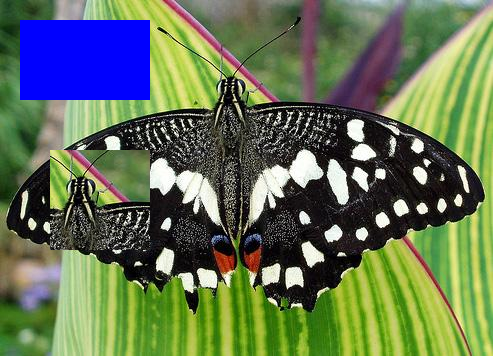

In [4]:
img_mod = img.copy()

# A. Cambiar color de un área rectangular (Azul en BGR: [255, 0, 0])
# Sintaxis: img[y1:y2, x1:x2]
img_mod[20:100, 20:150] = [255, 0, 0]

# B. Sustituir una región por otra (Copy-Paste)
region_interes = img[50:150, 200:300].copy()
img_mod[150:250, 50:150] = region_interes

print("Imagen Modificada:")
cv2_imshow(img_mod)

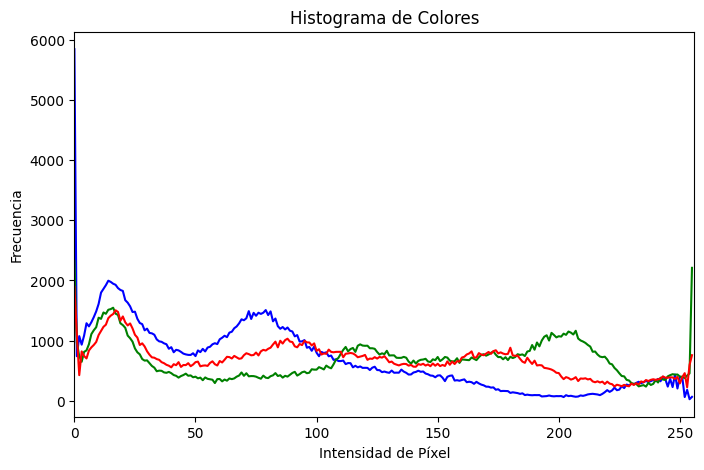

In [6]:
# Calcular histograma para cada canal
color = ('b', 'g', 'r')
plt.figure(figsize=(8, 5))

for i, col in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.title('Histograma de Colores')
plt.xlabel('Intensidad de Píxel')
plt.ylabel('Frecuencia')
plt.show()

Comparativa: Original vs Ajustada


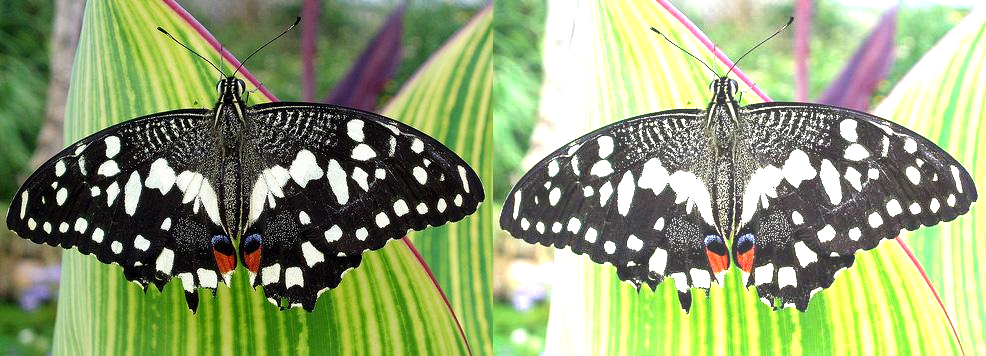

In [7]:
# Método A: Manual con NumPy
alpha = 1.5 # Contraste (1.0-3.0)
beta = 50   # Brillo (0-100)
img_manual = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

# Método B: OpenCV (Más eficiente)
img_cv2 = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

print("Comparativa: Original vs Ajustada")
cv2_imshow(np.hstack((img, img_cv2)))

In [8]:
from ipywidgets import interact, IntSlider

def ajustar_interactivo(brillo, contraste):
    # El contraste suele ser decimal, dividimos por 10
    c = contraste / 10.0
    ajustada = cv2.convertScaleAbs(img, alpha=c, beta=brillo)
    cv2_imshow(ajustada)

interact(ajustar_interactivo,
         brillo=IntSlider(min=-100, max=100, step=1, value=0),
         contraste=IntSlider(min=10, max=30, step=1, value=10))

interactive(children=(IntSlider(value=0, description='brillo', min=-100), IntSlider(value=10, description='con…

<function __main__.ajustar_interactivo(brillo, contraste)>